
# Lab 6: Linear Regression, Gradient Descent & Overfitting/Underfitting
**Student Name:** Shaheer Khan  
**Registration No:** 22JZELE0457  

This notebook covers three key topics:
1. **Linear Regression with scikit‑learn** – applied to Ohm's Law data.
2. **Gradient Descent from scratch** – implementing GD for linear regression with normalisation and rescaling.
3. **Overfitting vs. Underfitting** – polynomial regression on projectile motion data.



## Part 1: Linear Regression – Ohm's Law (1 kΩ Resistor)

### Objective
Fit a linear regression model to synthetic voltage‑current data generated from Ohm's Law:
$$ V = I \cdot R $$
where $ R = 1000 \, \Omega $. We will:
- Generate synthetic data with noise.
- Fit a linear model using `sklearn.linear_model.LinearRegression`.
- Compute MAE and RMSE.
- Visualise the regression line.


In [6]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set true resistance
R_true = 1000  # ohms

# Generate synthetic current (I) between 0 and 10 mA
I = np.linspace(0, 0.01, 50).reshape(-1, 1)  # Amperes

# Generate voltage using Ohm's Law: V = IR
V_clean = R_true * I.flatten()

# Add small measurement noise (std 0.05 V)
np.random.seed(42)
noise = np.random.normal(0, 0.05, size=I.shape[0])
V_noisy = V_clean + noise

print("Data shape:", I.shape)
print("First 5 points:\n", np.hstack((I[:5], V_noisy[:5].reshape(-1, 1))))


Data shape: (50, 1)
First 5 points:
 [[0.00000000e+00 2.48357077e-02]
 [2.04081633e-04 1.97168418e-01]
 [4.08163265e-04 4.40547692e-01]
 [6.12244898e-04 6.88396391e-01]
 [8.16326531e-04 8.04618862e-01]]


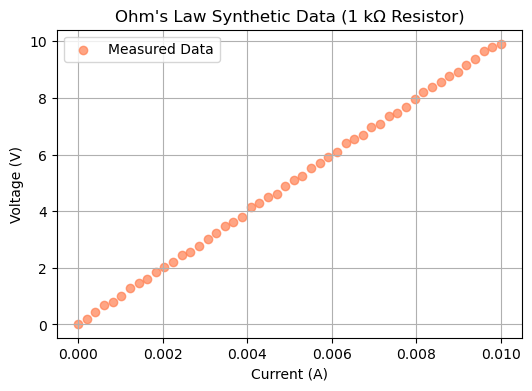

In [7]:

# Plot raw data
plt.figure(figsize=(6,4))
plt.scatter(I, V_noisy, label="Measured Data", color='coral', alpha=0.7)
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Ohm's Law Synthetic Data (1 kΩ Resistor)")
plt.grid(True)
plt.legend()
plt.show()


In [8]:

# Generate test data (5 points between 0 and 20 mA)
I_test = np.linspace(0, 0.02, 5).reshape(-1, 1)
V_test_clean = R_true * I_test.flatten()
V_test_noisy = V_test_clean + np.random.normal(0, 0.05, size=I_test.shape[0])

# Fit Linear Regression using sklearn
model = LinearRegression()
model.fit(I, V_noisy)

print("Model coefficient (slope)  :", model.coef_[0])
print("Model intercept            :", model.intercept_)
print("Expected slope (R_true)    :", R_true)


Model coefficient (slope)  : 997.1008300254084
Model intercept            : 0.0032221546101514065
Expected slope (R_true)    : 1000


In [9]:

# Predict on test set
V_pred = model.predict(I_test)

# Compute metrics
MAE = mean_absolute_error(V_test_noisy, V_pred)
RMSE = np.sqrt(mean_squared_error(V_test_noisy, V_pred))

print("MAE  :", MAE)
print("RMSE :", RMSE)


MAE  : 0.04123988959087501
RMSE : 0.05765264517215898


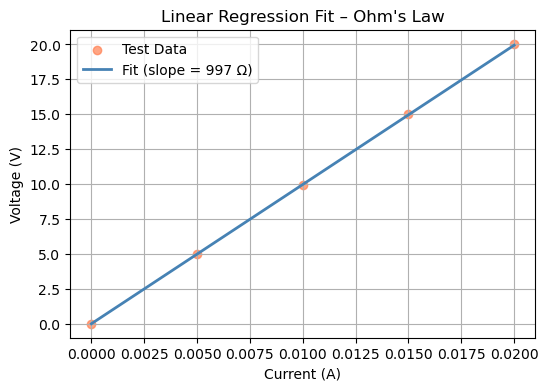

In [10]:

# Plot regression line
plt.figure(figsize=(6,4))
plt.scatter(I_test, V_test_noisy, label="Test Data", color='coral', alpha=0.7)
plt.plot(I_test, V_pred, color='steelblue', linewidth=2, label=f"Fit (slope = {model.coef_[0]:.0f} Ω)")
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Linear Regression Fit – Ohm's Law")
plt.grid(True)
plt.legend()
plt.show()



## Part 2: Gradient Descent from Scratch

### Objective
Implement gradient descent manually for linear regression on **normalised** data, then rescale the parameters back to physical units.

### Why Normalise?
Gradient descent converges faster when features are on a similar scale. We normalise using:
$$ I_{norm} = \frac{I - \mu_I}{\sigma_I}, \qquad V_{norm} = \frac{V - \mu_V}{\sigma_V} $$

### Gradient Descent Updates
- Prediction: $ \hat{V}_{norm} = m \cdot I_{norm} + b $
- Loss: $ \mathcal{L} = \frac{1}{N} \sum (\hat{V}_{norm} - V_{norm})^2 $
- Gradients:
$$ \frac{\partial\mathcal{L}}{\partial m} = \frac{2}{N} \sum I_{norm} \cdot (\hat{V}_{norm} - V_{norm}), \qquad
   \frac{\partial\mathcal{L}}{\partial b} = \frac{2}{N} \sum (\hat{V}_{norm} - V_{norm}) $$
- Update:
$$ m \leftarrow m - \alpha \cdot \frac{\partial\mathcal{L}}{\partial m}, \qquad
   b \leftarrow b - \alpha \cdot \frac{\partial\mathcal{L}}{\partial b} $$

### Rescaling to Physical Units
After training, we rescale:
$$ m_{phys} = m \cdot \frac{\sigma_V}{\sigma_I}, \qquad
   b_{phys} = b \cdot \sigma_V + \mu_V - m_{phys} \cdot \mu_I $$


In [11]:

# Use the same data as before
I_flat = I.flatten()
V_flat = V_noisy

# Normalise
I_mean, I_std = I_flat.mean(), I_flat.std()
V_mean, V_std = V_flat.mean(), V_flat.std()

I_norm = (I_flat - I_mean) / I_std
V_norm = (V_flat - V_mean) / V_std

print(f"I_mean: {I_mean:.6f}, I_std: {I_std:.6f}")
print(f"V_mean: {V_mean:.6f}, V_std: {V_std:.6f}")


I_mean: 0.005000, I_std: 0.002945
V_mean: 4.988726, V_std: 2.936888


In [12]:

# Gradient Descent implementation
alpha = 0.05
m, b = 1.0, 100.0
loss_history = []
converged_epoch = None

for epoch in range(500):
    V_pred_norm = m * I_norm + b
    error = V_pred_norm - V_norm

    loss = (error ** 2).mean()
    loss_history.append(float(loss))

    dm = 2 * (I_norm * error).mean()
    db = 2 * error.mean()

    m -= alpha * dm
    b -= alpha * db

    if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < 1e-9:
        converged_epoch = epoch
        break

if converged_epoch is None:
    converged_epoch = 499

print(f"Converged at epoch {converged_epoch}")
print(f"Final normalised parameters: m = {m:.6f}, b = {b:.6f}")


Converged at epoch 136
Final normalised parameters: m = 0.999880, b = 0.000054


In [13]:

# Rescale to physical units
m_phys = m * (V_std / I_std)
b_phys = b * V_std + V_mean - m_phys * I_mean

print(f"GD slope     : {m_phys:.2f} Ω  (expected 1000)")
print(f"GD intercept : {b_phys:.4f} V  (expected ~0)")


GD slope     : 997.10 Ω  (expected 1000)
GD intercept : 0.0034 V  (expected ~0)


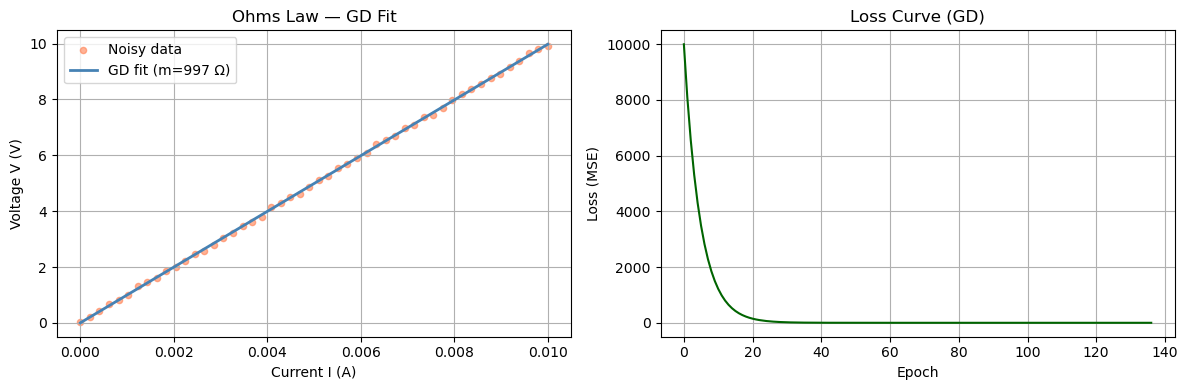

In [15]:

# Plot GD fit and loss curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Fit plot
ax1.scatter(I_flat, V_flat, s=20, alpha=0.6, color='coral', label='Noisy data')
ax1.plot(I_flat, m_phys * I_flat + b_phys, color='steelblue', linewidth=2,
         label=f'GD fit (m={m_phys:.0f} Ω)')
ax1.set_xlabel('Current I (A)')
ax1.set_ylabel('Voltage V (V)')
ax1.set_title('Ohms Law — GD Fit')
ax1.legend()
ax1.grid(True)

# Loss curve
ax2.plot(loss_history, color='darkgreen')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (MSE)')
ax2.set_title('Loss Curve (GD)')
ax2.grid(True)

plt.tight_layout()
plt.show()



## Part 3: Overfitting vs Underfitting – Projectile Motion

### Objective
Demonstrate underfitting and overfitting using polynomial regression on synthetic projectile motion data.

**True Physics:** Height follows a parabola:
$$ h(t) = -4.9t^2 + 20t + 2 $$

**Models:**
- **Degree 1** → underfits (straight line on a curve).
- **Degree 2** → perfect (matches true physics).
- **Degree 10** → overfits (chases noise).

### Key Metrics
We compare **Train MSE** and **Test MSE** to diagnose underfitting/overfitting.


In [16]:

# Generate projectile motion data
np.random.seed(42)

# True parameters
a, b_coef, c = -4.9, 20, 2

t = np.linspace(0, 4, 40)        # 0 to 4 seconds, 40 measurements
h_true = a * t**2 + b_coef * t + c
noise = np.random.normal(0, 1.5, size=t.shape)
h_noisy = h_true + noise

# Train / Test split
t_train, h_train = t[:30], h_noisy[:30]
t_test,  h_test  = t[30:], h_noisy[30:]

print("Train size:", len(t_train))
print("Test size :", len(t_test))


Train size: 30
Test size : 10


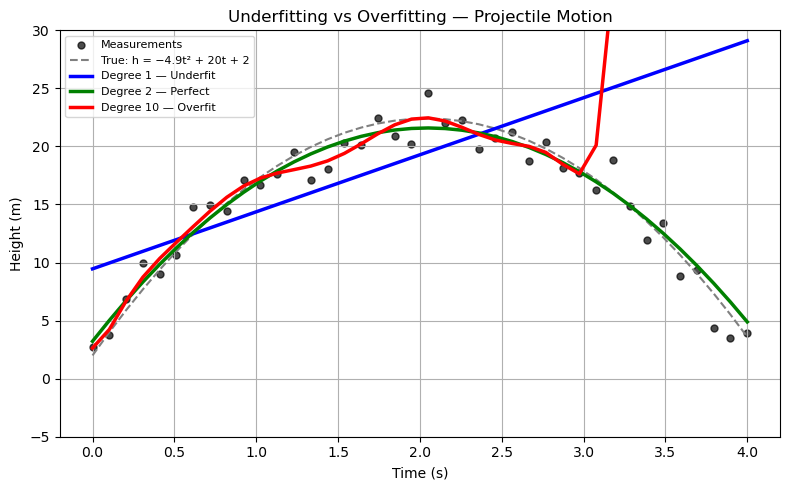

In [17]:

# Fit polynomials of degrees 1, 2, and 10
degrees = [1, 2, 10]
colors = ['blue', 'green', 'red']
labels = [
    'Degree 1 — Underfit',
    'Degree 2 — Perfect',
    'Degree 10 — Overfit'
]

plt.figure(figsize=(8, 5))
plt.scatter(t, h_noisy, color='black', s=25, alpha=0.7, label='Measurements')
plt.plot(t, h_true, color='gray', linestyle='--', linewidth=1.5, label='True: h = −4.9t² + 20t + 2')

for d, color, label in zip(degrees, colors, labels):
    coeffs = np.polyfit(t_train, h_train, d)
    h_fit = np.polyval(coeffs, t)
    plt.plot(t, h_fit, color=color, linewidth=2.5, label=label)

plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Underfitting vs Overfitting — Projectile Motion')
plt.ylim(-5, 30)
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:

# Compute and display metrics
print(f"{'Degree':<10} {'Train MSE':<15} {'Test MSE':<15} {'Verdict'}")
print("-" * 65)

verdicts = {
    1:  "❌ Underfit  — straight line misses the parabola",
    2:  "✅ Perfect   — matches true physics exactly",
    10: "❌ Overfit   — memorised noise, fails on new data"
}

for d in [1, 2, 10]:
    coeffs = np.polyfit(t_train, h_train, d)
    train_mse = np.mean((np.polyval(coeffs, t_train) - h_train) ** 2)
    test_mse = np.mean((np.polyval(coeffs, t_test) - h_test) ** 2)
    print(f"{d:<10} {train_mse:<15.3f} {test_mse:<15.3f} {verdicts[d]}")

print("\nKey Insight:")
print("  Degree 2  → lowest Test MSE  — model learned the physics")
print("  Degree 10 → tiny Train MSE but huge Test MSE — memorised noise")


Degree     Train MSE       Test MSE        Verdict
-----------------------------------------------------------------
1          10.930          308.927         ❌ Underfit  — straight line misses the parabola
2          1.421           4.331           ✅ Perfect   — matches true physics exactly
10         1.094           14271192.554    ❌ Overfit   — memorised noise, fails on new data

Key Insight:
  Degree 2  → lowest Test MSE  — model learned the physics
  Degree 10 → tiny Train MSE but huge Test MSE — memorised noise



## Summary

This combined lab covered:

1. **Linear Regression with sklearn** – fitting Ohm's Law data, computing MAE/RMSE.
2. **Gradient Descent from scratch** – implementing GD on normalised data and rescaling to physical units.
3. **Overfitting vs Underfitting** – polynomial regression on projectile motion data, diagnosing model complexity.

All three parts demonstrate fundamental concepts in supervised learning and model evaluation.

---

**Prepared by:** Shaheer Khan (22JZELE0457)  
